In [ ]:
import os
import json
import time
import argparse
from typing import Tuple, Optional
import re

import numpy as np
from scipy.optimize import minimize

#few and SEF imports
from few.waveform import GenerateEMRIWaveform
from few.waveform.waveform import SuperKludgeWaveform

from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode.flux import KerrEccEqFlux
from few.utils.geodesic import get_fundamental_frequencies
from scipy.interpolate import CubicSpline
from scipy.integrate import cumulative_trapezoid
from few.utils.constants import MTSUN_SI

from fastlisaresponse import ResponseWrapper
from lisatools.detector import EqualArmlengthOrbits
from lisatools.sensitivity import get_sensitivity, A1TDISens, E1TDISens, T1TDISens
from stableemrifisher.utils import generate_PSD, inner_product
from stableemrifisher.fisher import StableEMRIFisher
import matplotlib.pyplot as plt

from config_paris import Config, ObjectiveTracker
from misc import *
from misc import fishinv

try:
    import cupy as cp
    xp=cp
except:
    xp=np
    print("CuPy not found, using NumPy instead. For GPU acceleration, please install CuPy.")

from inference import  prepare_true_waveform

In [ ]:
seed= 42   
param_names_to_infer = ['m1', 'm2', 'a', 'p0', 'e0', 'qS', 'phiS', 'Phi_phi0', 'Phi_r0']  
params_name = ["m1","m2","a","p0","e0","xI0","dist","qS","phiS","qK","phiK",
                         "Phi_phi0","Phi_theta0","Phi_r0"]      

params = np.array([1e6,1e1,0.9, 7.5,  5.00000000e-01,  1.00000000e+00,
          5.0,  np.pi/4,  1.0, 1,  np.pi/3,  9.00000000e-01, 5.00000000e-01,  4.00000000e-01])

signal_param = {"m1": 1e6,
    "m2": 10.0,
    "a": 0.9,
    "p0": 7.5,
    "e0": 0.5,
    "xI0": 1.0,
    "dist": 5.0,
    "qS": np.pi/4,
    "phiS": 1,
    "qK": 1,
    "phiK": np.pi/3,
    "Phi_phi0": 0.9,
    "Phi_theta0": 0.5,
    "Phi_r0": 4.00000000e-01,
}
signal_param_array = np.array(list(signal_param.values()))
dt = 10  #Time step for waveform generation; default 0.1s
T= 1.0

chi2 = 0.0 
dev_1 = 0.0
dev_2 = 0.0

emri_kwargs = {"T": T, "dt": dt,'chi2': chi2,'evolve_1PA': True,'evolve_primary': False,'evolve_2PA': False,'deviation_included': True,
                   'dev_1': dev_1, 'dev_2': dev_2}
add_kwargs = {'chi2': chi2,'evolve_1PA': True,'evolve_primary': False,'evolve_2PA': False,'deviation_included': True,
                   'dev_1': dev_1, 'dev_2': dev_2}

# if target_func in ('optimal_snr', 'optimal_snr_phase_max','time_max'):
        
ctx = prepare_true_waveform(signal_param_array, emri_kwargs, add_kwargs,add_noise=True, use_gpu=True,seed=seed)

snr_2 = inner_prod(ctx['waveform_true_fft_without_noise'], ctx['waveform_true_fft_without_noise'], ctx['PSD_funcs'], ctx['delta_f'], xp=xp)
ctx

In [6]:
use_gpu = True
channels = [A1TDISens, E1TDISens, T1TDISens]
noise_kwargs = [{"sens_fn": ch} for ch in channels]

sef = StableEMRIFisher(waveform_class=SuperKludgeWaveform,
                       waveform_class_kwargs = dict(sum_kwargs=dict(pad_output=False, odd_len=True)),
                       waveform_generator = GenerateEMRIWaveform,
                       waveform_generator_kwargs= dict(return_list=False),
                       ResponseWrapper=ResponseWrapper,
                       ResponseWrapper_kwargs = dict(Tobs=ctx['T'],
                                                    t0=10000.0,
                                                    dt=ctx['dt'],
                                                    index_lambda=8,
                                                    index_beta=7,
                                                    flip_hx=True,
                                                    is_ecliptic_latitude=False,
                                                    remove_garbage="zero",
                                                    orbits=EqualArmlengthOrbits(use_gpu=use_gpu),
                                                    force_backend = "cuda12x" if use_gpu else "cpu",
                                                    order=20,
                                                    tdi="1st generation",
                                                    tdi_chan="AET"),
                       stats_for_nerds = True, use_gpu = use_gpu,
                       deriv_type='stable',
                       noise_model=get_sensitivity,
                       noise_kwargs=noise_kwargs,
                       channels=channels,
                       T = ctx['T'], dt = ctx['dt'],
                       stability_plot = False,
                       der_order = 10, Ndelta = 20,
                       plunge_check=True, return_derivatives=False
                       )
emri_kwargs = {"T":ctx['T'], "dt":ctx['dt']}



waveform shape: (3, 3155814)
wave ndim: 2
Computing SNR for parameters: (999894.8642207884, 9.999204206491733, 0.8999403453809603, 7.5003883272499, 0.500021423957347, np.float64(1.0), np.float64(5.0), 0.7911479980488584, 1.0103259004865965, np.float64(1.0), np.float64(1.0471975511965976), 1.0674353740287845, np.float64(0.5), 0.3675965889561167, 0.0, True, False, False, False, 0, 0)
SNR:  180.09464635457394
Body is not plunging, Fisher should be stable.
waveform shape: (3, 3155814)
wave ndim: 2
Computing SNR for parameters: (999894.8642207884, 9.999204206491733, 0.8999403453809603, 7.5003883272499, 0.500021423957347, np.float64(1.0), np.float64(5.0), 0.7911479980488584, 1.0103259004865965, np.float64(1.0), np.float64(1.0471975511965976), 1.0674353740287845, np.float64(0.5), 0.3675965889561167, 0.0, True, False, False, False, 0, 0)
Waveform Generated. SNR: 180.09464635457394
calculating stable deltas...
Gamma_ii for m1: 67185.25457516834
Gamma_ii for m1: 67185.26202147432
Gamma_ii for m1

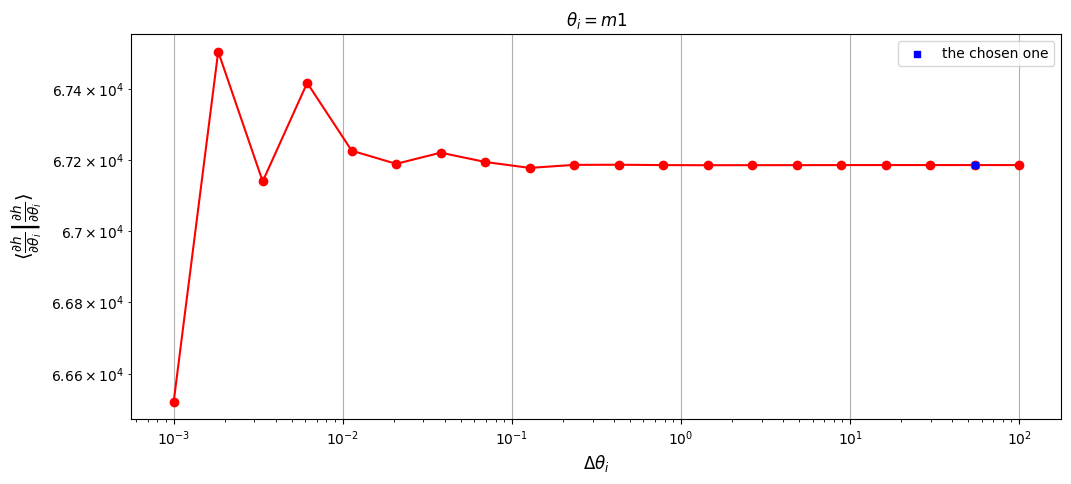

Gamma_ii for m2: 40956947271875.58
Gamma_ii for m2: 40956918916249.836
Gamma_ii for m2: 40956998405496.766
Gamma_ii for m2: 40956941999917.63
Gamma_ii for m2: 40956621930460.27
Gamma_ii for m2: 40957250185013.96
Gamma_ii for m2: 40955461805572.16
Gamma_ii for m2: 40957556265469.875
Gamma_ii for m2: 40955809420730.22
Gamma_ii for m2: 40959030868014.64
Gamma_ii for m2: 40957884441031.8
Gamma_ii for m2: 40941104170433.93
Gamma_ii for m2: 40975550246293.17
Gamma_ii for m2: 41043229662148.96
Gamma_ii for m2: 40965686613421.85
Gamma_ii for m2: 41057178048178.266
Gamma_ii for m2: 41531583768081.08
Gamma_ii for m2: 40843556935220.63
Gamma_ii for m2: 41751237975324.83
Gamma_ii for m2: 39328121773930.64
[np.float64(6.923280972421312e-07), np.float64(1.9407976664378655e-06), np.float64(1.3771921529914498e-06), np.float64(7.8148402449503e-06), np.float64(1.533927572894957e-05), np.float64(4.3666445523057714e-05), np.float64(5.1137325775574365e-05), np.float64(4.265194033186574e-05), np.float64(7.8

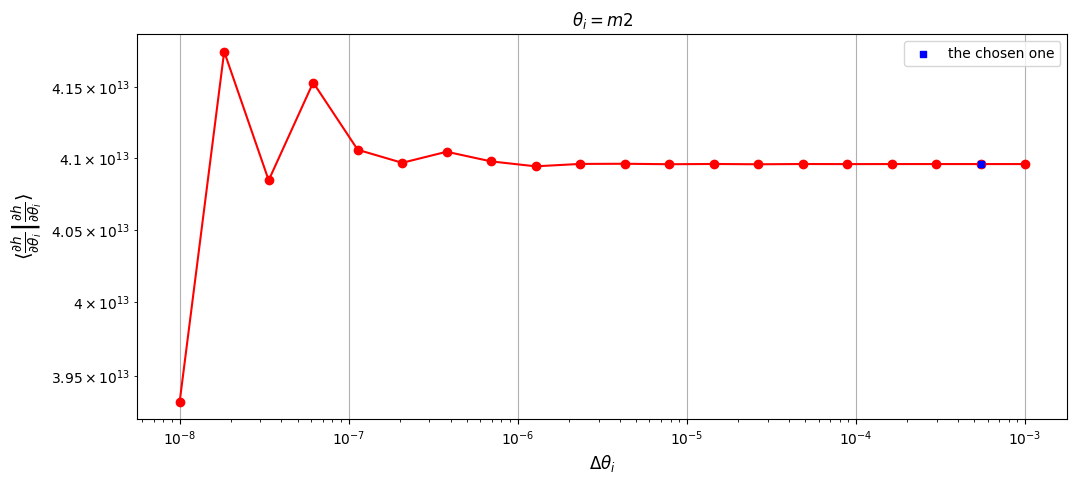

Gamma_ii for a: 3314932009857355.5
Gamma_ii for a: 3314932516958208.5
Gamma_ii for a: 3314941528060314.0
Gamma_ii for a: 3314945595752136.5
Gamma_ii for a: 3314951138133730.5
Gamma_ii for a: 3314942591277736.5
Gamma_ii for a: 3314929925988389.0
Gamma_ii for a: 3314934370073492.5
Gamma_ii for a: 3314468417251284.5
Gamma_ii for a: 3315750022452314.0
Gamma_ii for a: 3315434771565542.0
Gamma_ii for a: 3313844468639148.0
Gamma_ii for a: 3318935477210573.0
Gamma_ii for a: 3319281676067221.0
Gamma_ii for a: 3317740555349758.0
Gamma_ii for a: 3312601079332344.5
Gamma_ii for a: 3387567711744125.5
Gamma_ii for a: 3380332693144103.0
Gamma_ii for a: 3403306869120731.5
Gamma_ii for a: 3264851859957461.0
[np.float64(1.5297471378552138e-07), np.float64(2.718329125633991e-06), np.float64(1.2270764949242164e-06), np.float64(1.6719346268012507e-06), np.float64(2.5782817525976023e-06), np.float64(3.82068086815551e-06), np.float64(1.3406253661068632e-06), np.float64(0.00014058146391825283), np.float64(0.0

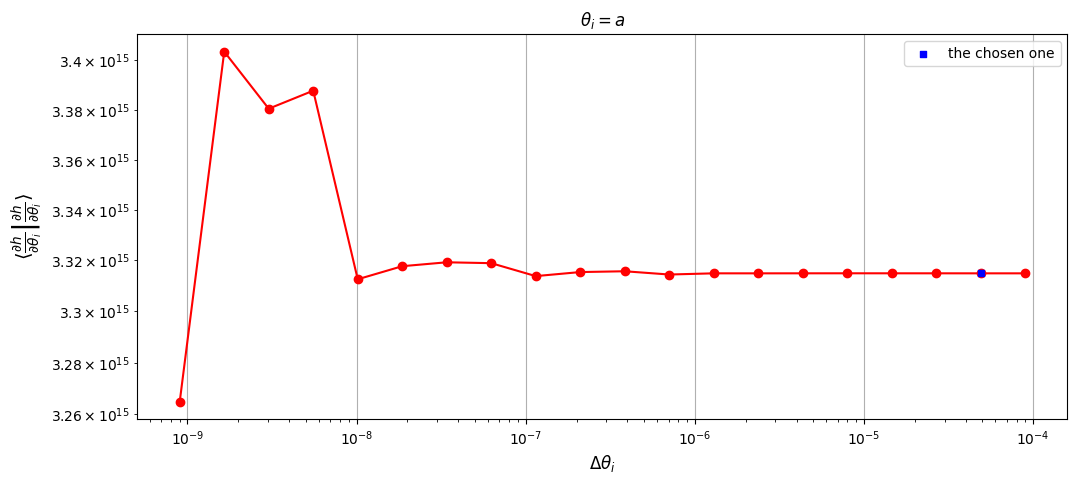

Gamma_ii for p0: 3271420803267171.5
Gamma_ii for p0: 3271421462083507.0
Gamma_ii for p0: 3271420465410608.0
Gamma_ii for p0: 3271419662850514.0
Gamma_ii for p0: 3271419666127851.0
Gamma_ii for p0: 3271411473252688.0
Gamma_ii for p0: 3271431714304279.5
Gamma_ii for p0: 3271422042111382.5
Gamma_ii for p0: 3271418617412165.5
Gamma_ii for p0: 3271380628834785.0
Gamma_ii for p0: 3271478353260673.5
Gamma_ii for p0: 3271660122096516.0
Gamma_ii for p0: 3271260891902630.0
Gamma_ii for p0: 3270341835511538.0
Gamma_ii for p0: 3271087277250769.5
Gamma_ii for p0: 3271689118080175.0
Gamma_ii for p0: 3278195300977712.5
Gamma_ii for p0: 3280428918627132.5
Gamma_ii for p0: 3266395856667125.0
Gamma_ii for p0: 3305935650495440.5
[np.float64(2.013853436910609e-07), np.float64(3.0466059301701653e-07), np.float64(2.4532471425591986e-07), np.float64(1.001808796937127e-09), np.float64(2.5043854097797167e-06), np.float64(6.187215066417663e-06), np.float64(2.9565714152728356e-06), np.float64(1.0468544743164315e

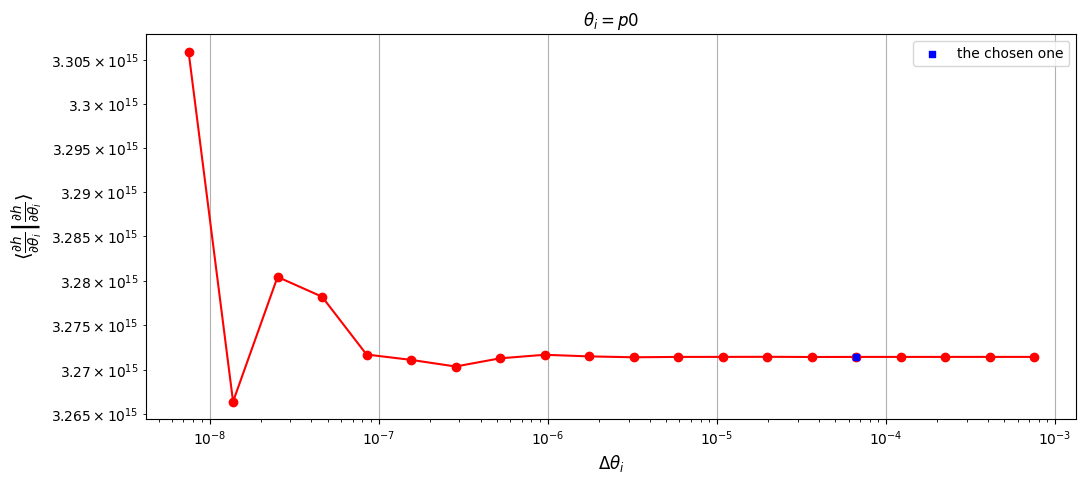

Gamma_ii for e0: 2.5179691649545204e+16
Gamma_ii for e0: 2.5179657620771036e+16
Gamma_ii for e0: 2.5179707248669396e+16
Gamma_ii for e0: 2.5179655009713296e+16
Gamma_ii for e0: 2.517966129324655e+16
Gamma_ii for e0: 2.5179716190797196e+16
Gamma_ii for e0: 2.517996209588815e+16
Gamma_ii for e0: 2.517941765264138e+16
Gamma_ii for e0: 2.517968445366817e+16
Gamma_ii for e0: 2.5183742656908064e+16
Gamma_ii for e0: 2.5168670564702616e+16
Gamma_ii for e0: 2.518587551144836e+16
Gamma_ii for e0: 2.5199363255168916e+16
Gamma_ii for e0: 2.5177817764306692e+16
Gamma_ii for e0: 2.512729789885534e+16
Gamma_ii for e0: 2.5060444682006508e+16
Gamma_ii for e0: 2.5216217949798308e+16
Gamma_ii for e0: 2.4899103521075044e+16
Gamma_ii for e0: 2.543645485749425e+16
Gamma_ii for e0: 2.369080671349188e+16
[np.float64(1.3514391132915648e-06), np.float64(1.97094818735919e-06), np.float64(2.0746493976922368e-06), np.float64(2.495479658292826e-07), np.float64(2.1802291268105803e-06), np.float64(9.76590393661299e-0

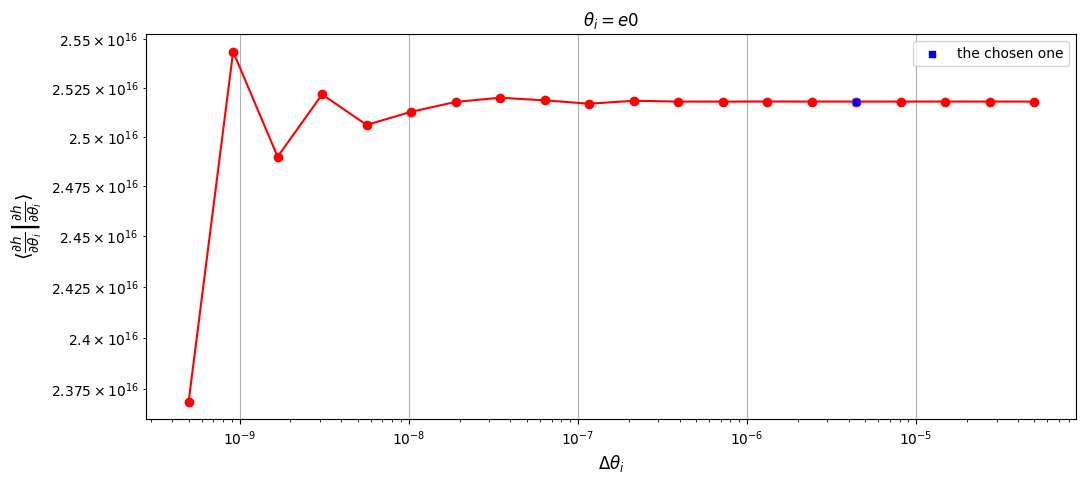

Gamma_ii for qS: 1115212.500920606
Gamma_ii for qS: 1722007.3255151045
Gamma_ii for qS: 1598671.2241007918
Gamma_ii for qS: 1524855.3503229881
Gamma_ii for qS: 1483612.801991538
Gamma_ii for qS: 1725809.4055231356
Gamma_ii for qS: 1458766.2524615144
Gamma_ii for qS: 616115.4891548133
Gamma_ii for qS: 2382289.0309117516
Gamma_ii for qS: 1603890.18299277
Gamma_ii for qS: 1817467.0594057064
Gamma_ii for qS: 1744880.6554067475
Gamma_ii for qS: 1763068.309075699
Gamma_ii for qS: 1764641.5133603374
Gamma_ii for qS: 1744734.5098968716
Gamma_ii for qS: 1734405.0777875076
Gamma_ii for qS: 1744924.4841135342
Gamma_ii for qS: 1743223.159994474
Gamma_ii for qS: 1741614.9081857803
Gamma_ii for qS: 1738021.9315812704
[np.float64(0.35237644788356964), np.float64(0.07714913457811548), np.float64(0.04840844330720837), np.float64(0.02779872772470552), np.float64(0.14033797866467293), np.float64(0.1830609616934954), np.float64(1.3676831343140694), np.float64(0.7413766838698774), np.float64(0.485319291914

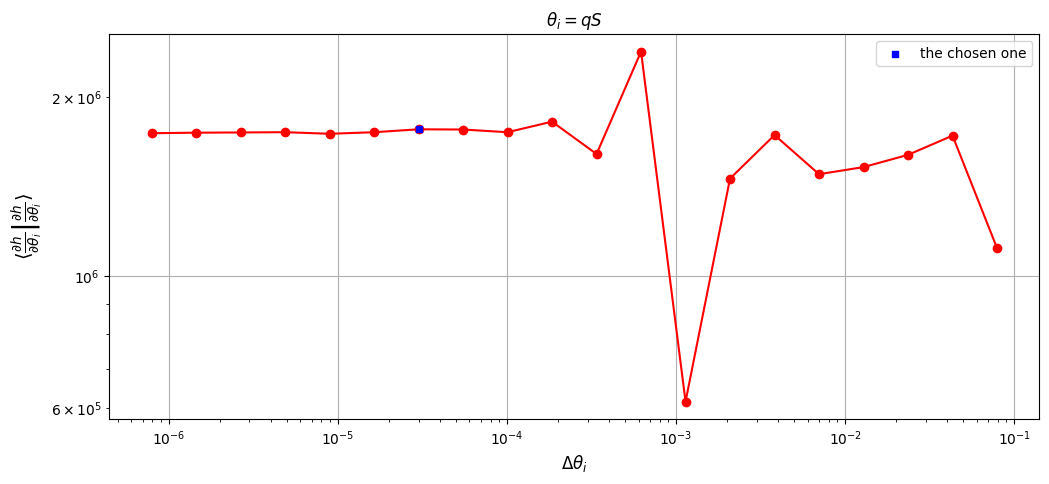

Gamma_ii for phiS: 8233305.790355801
Gamma_ii for phiS: 9599746.251686316
Gamma_ii for phiS: 9769012.702426638
Gamma_ii for phiS: 9817850.892777894
Gamma_ii for phiS: 9840983.557128549
Gamma_ii for phiS: 9671665.856568333
Gamma_ii for phiS: 9759332.486850835
Gamma_ii for phiS: 9683934.153443549
Gamma_ii for phiS: 9707347.545642074
Gamma_ii for phiS: 9700133.009401027
Gamma_ii for phiS: 9699218.632134918
Gamma_ii for phiS: 9702716.533440698
Gamma_ii for phiS: 9696087.857428363
Gamma_ii for phiS: 9686767.875670062
Gamma_ii for phiS: 9725790.026087837
Gamma_ii for phiS: 9644073.22434673
Gamma_ii for phiS: 9574356.10935272
Gamma_ii for phiS: 9622544.351801552
Gamma_ii for phiS: 9622290.766333673
Gamma_ii for phiS: 9616233.11998305
[np.float64(0.14234131043729234), np.float64(0.017326873850647816), np.float64(0.004974427793274095), np.float64(0.002350645564680193), np.float64(0.017506570540299103), np.float64(0.008982851071076799), np.float64(0.007785919669897318), np.float64(0.002411924790

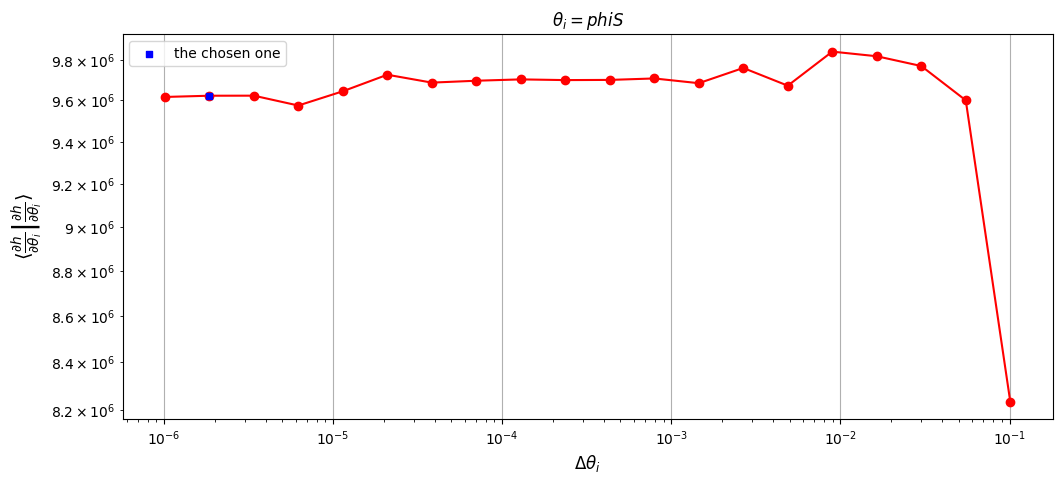

stable deltas: {'m1': 54.55021202960139, 'm2': 0.0005455160628477461, 'a': 4.90970985162336e-05, 'p0': 6.644344934290112e-05, 'e0': 4.429523739773744e-06, 'qS': 3.0005792516173643e-05, 'phiS': 1.851907887246346e-06, 'Phi_phi0': 0.0, 'Phi_r0': 0.0}
Time taken to compute stable deltas is 39.959630250930786 seconds
calculating Fisher matrix...
Finished derivatives
Calculated Fisher is *atleast* positive-definite.
Time taken to compute FM is 1.8853843212127686 seconds


In [9]:
x_best_fit_1PA = [999894.8642207884, 9.999204206491733, 0.8999403453809603, 7.5003883272499, 0.500021423957347, 0.7911479980488584, 1.0103259004865965, 1.0674353740287845, 0.3675965889561167]

add_kwargs_1PA = {'chi2': 0.0, 'evolve_1PA': True, 'evolve_primary': False,
                      'evolve_2PA': False, 'deviation_included': False,
                      'dev_1': 0, 'dev_2': 0}

m1, m2, a, p0, e0,qS,phiS,Phi_phi0,Phi_r0 = x_best_fit_1PA
wave_params = [m1, m2, a, p0, e0, ctx['Y0'],ctx['dist'],qS,phiS, ctx['qK'], ctx['phiK'], 
                    Phi_phi0, ctx['Phi_theta0'], Phi_r0,add_kwargs_1PA['chi2'],add_kwargs_1PA['evolve_1PA'],add_kwargs_1PA['evolve_primary'],
                    add_kwargs_1PA['evolve_2PA'], add_kwargs_1PA['deviation_included'],add_kwargs_1PA['dev_1'],add_kwargs_1PA['dev_2']]


param_names_to_infer = ['m1', 'm2', 'a', 'p0', 'e0', 'qS', 'phiS', 'Phi_phi0', 'Phi_r0']  
dim = len(param_names_to_infer)
param_names = param_names_to_infer
SNR = sef.SNRcalc_SEF(*wave_params,**emri_kwargs,use_gpu=use_gpu)
print("SNR: ", SNR)

param_dict = {
    'm1': wave_params[0],
    'm2': wave_params[1],
    'a': wave_params[2],
    'p0': wave_params[3],
    'e0': wave_params[4],
    'xI0': wave_params[5],
    'dist': wave_params[6],
    'qS': wave_params[7],
    'phiS': wave_params[8],
    'qK': wave_params[9],
    'phiK': wave_params[10],
    'Phi_phi0': wave_params[11],
    'Phi_theta0': wave_params[12],
    'Phi_r0': wave_params[13]}

Fisher_1PA = sef(wave_params = param_dict,param_names=param_names, add_param_args=add_kwargs_1PA,
            live_dangerously = False, stability_plot = True,der_order = 8, Ndelta = 20,return_derivatives = False)

# Covariance_fit_1PA = fishinv(m1, Fisher, index_of_M=0)


waveform shape: (3, 3155814)
wave ndim: 2
Computing SNR for parameters: (1000117.4489066871, 10.000747713536276, 0.9000821275834304, 7.499521999767378, 0.49998410573186125, np.float64(1.0), np.float64(5.0), 0.7832871364017695, 1.010973741062668, np.float64(1.0), np.float64(1.0471975511965976), 1.0747886916109437, np.float64(0.5), 0.38364873884565026, 0.0, False, False, False, True, 0, 0)
SNR:  179.90360494852357
Body is not plunging, Fisher should be stable.
waveform shape: (3, 3155814)
wave ndim: 2
Computing SNR for parameters: (1000117.4489066871, 10.000747713536276, 0.9000821275834304, 7.499521999767378, 0.49998410573186125, np.float64(1.0), np.float64(5.0), 0.7832871364017695, 1.010973741062668, np.float64(1.0), np.float64(1.0471975511965976), 1.0747886916109437, np.float64(0.5), 0.38364873884565026, 0.0, False, False, False, True, 0, 0)
Waveform Generated. SNR: 179.90360494852357
calculating stable deltas...
Gamma_ii for m1: 62697.92042441836
Gamma_ii for m1: 62697.92042469589
Gam

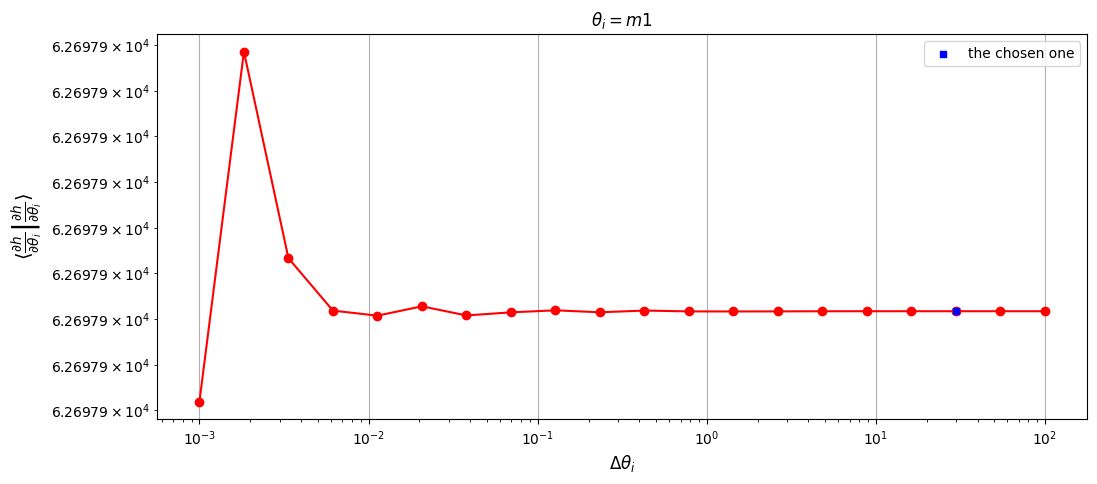

Gamma_ii for m2: 38243813711769.58
Gamma_ii for m2: 38243813712841.49
Gamma_ii for m2: 38243813712475.49
Gamma_ii for m2: 38243813708833.67
Gamma_ii for m2: 38243813713021.15
Gamma_ii for m2: 38243813714530.11
Gamma_ii for m2: 38243813697513.43
Gamma_ii for m2: 38243813710608.33
Gamma_ii for m2: 38243813726215.14
Gamma_ii for m2: 38243813830021.39
Gamma_ii for m2: 38243813619293.76
Gamma_ii for m2: 38243813702519.445
Gamma_ii for m2: 38243813383219.766
Gamma_ii for m2: 38243814029609.01
Gamma_ii for m2: 38243813921374.52
Gamma_ii for m2: 38243812534584.945
Gamma_ii for m2: 38243813279327.23
Gamma_ii for m2: 38243802569558.58
Gamma_ii for m2: 38243827776759.195
Gamma_ii for m2: 38243782945957.23
[np.float64(2.8028430180854928e-11), np.float64(9.57017526420508e-12), np.float64(9.522638982154652e-11), np.float64(1.0949422026585857e-10), np.float64(3.945634054081523e-11), np.float64(4.449524783823117e-10), np.float64(3.4240566426218233e-10), np.float64(4.0808724286045605e-10), np.float64(2

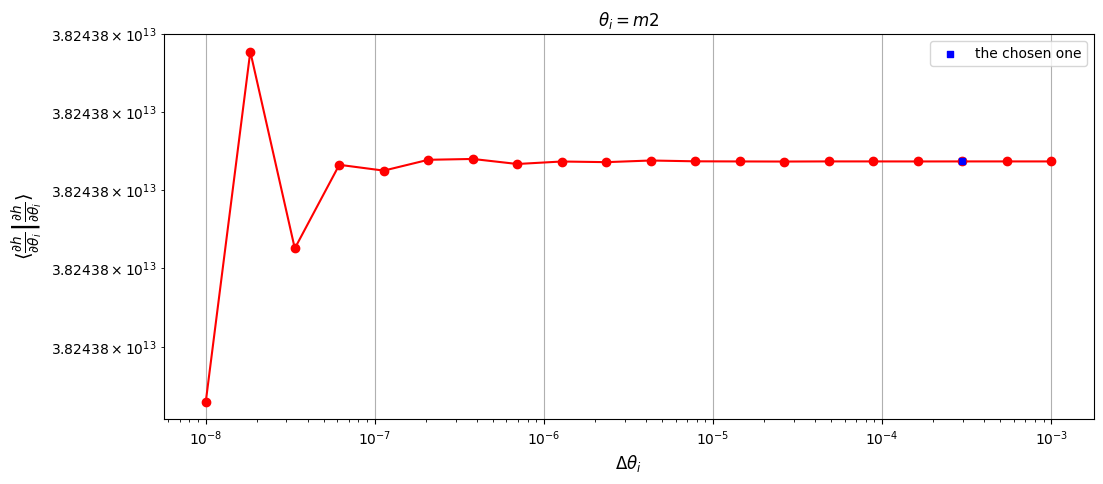

Gamma_ii for a: 3115662904250005.5
Gamma_ii for a: 3115657422908157.0
Gamma_ii for a: 3115660550696225.5
Gamma_ii for a: 3115652697238978.0
Gamma_ii for a: 3115662678721399.0
Gamma_ii for a: 3115651822620595.5
Gamma_ii for a: 3115712260091174.0
Gamma_ii for a: 3115658978017889.5
Gamma_ii for a: 3115945507092765.0
Gamma_ii for a: 3114901085217586.0
Gamma_ii for a: 3116431336612751.5
Gamma_ii for a: 3117413050618752.0
Gamma_ii for a: 3117105461862687.0
Gamma_ii for a: 3113653627144508.0
Gamma_ii for a: 3102435284326939.0
Gamma_ii for a: 3131111775136512.5
Gamma_ii for a: 3149372825170353.0
Gamma_ii for a: 3125347053608184.5
Gamma_ii for a: 3018322302522319.0
Gamma_ii for a: 3423988874431508.0
[np.float64(1.7592890053309236e-06), np.float64(1.003892438732154e-06), np.float64(2.5206459161701682e-06), np.float64(3.2036466878038882e-06), np.float64(3.4843754763229165e-06), np.float64(1.9397641865918466e-05), np.float64(1.710138165326323e-05), np.float64(9.19557399907282e-05), np.float64(0.00

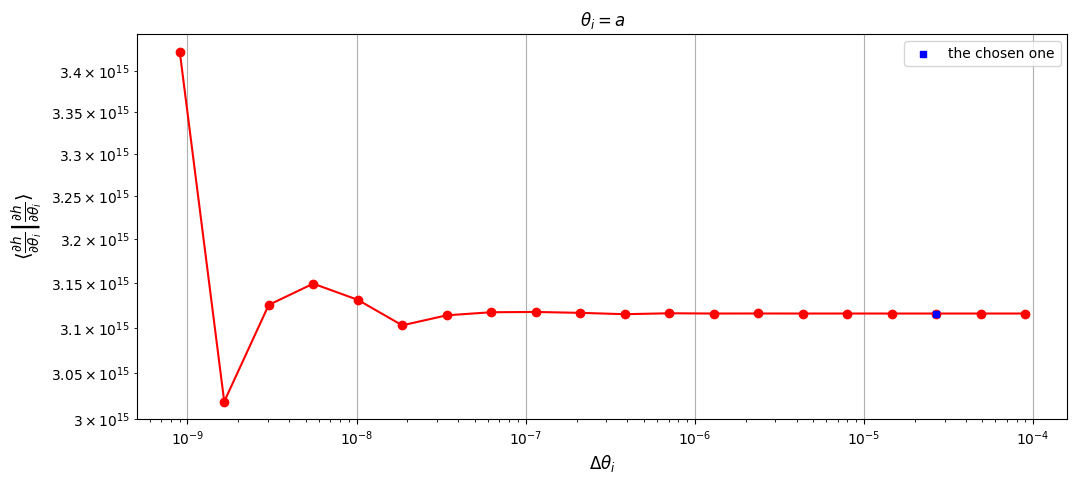

Gamma_ii for p0: 3057526290193152.0
Gamma_ii for p0: 3057527191911057.5
Gamma_ii for p0: 3057526337235938.0
Gamma_ii for p0: 3057525928512355.0
Gamma_ii for p0: 3057526223083753.5
Gamma_ii for p0: 3057526846861629.0
Gamma_ii for p0: 3057517065272677.5
Gamma_ii for p0: 3057551909004107.5
Gamma_ii for p0: 3057517296774703.5
Gamma_ii for p0: 3057509900788524.5
Gamma_ii for p0: 3057547934098184.0
Gamma_ii for p0: 3057679306754355.0
Gamma_ii for p0: 3057911757501252.5
Gamma_ii for p0: 3057422350860386.5
Gamma_ii for p0: 3057849872860404.0
Gamma_ii for p0: 3056872451812503.5
Gamma_ii for p0: 3057326801333931.0
Gamma_ii for p0: 3047089607436309.5
Gamma_ii for p0: 3069083227807140.0
Gamma_ii for p0: 3043307959696088.5
[np.float64(2.9491737894778817e-07), np.float64(2.7953156415739743e-07), np.float64(1.336778796178076e-07), np.float64(9.634304892499066e-08), np.float64(2.0401386700505058e-07), np.float64(3.199193575270414e-06), np.float64(1.1395957441438549e-05), np.float64(1.1320370759802913e

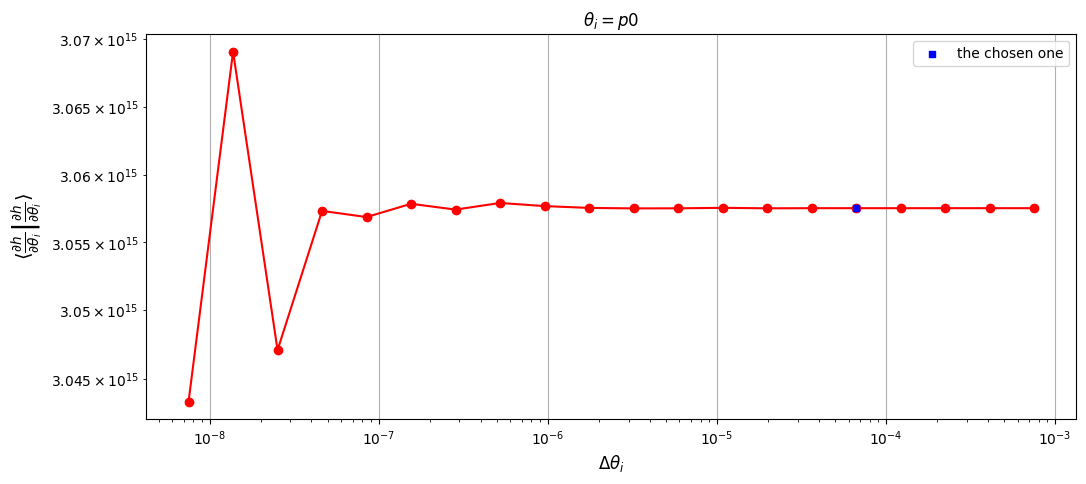

Gamma_ii for e0: 2.3507953747896396e+16
Gamma_ii for e0: 2.350796334537559e+16
Gamma_ii for e0: 2.3507901485158156e+16
Gamma_ii for e0: 2.3507940807428564e+16
Gamma_ii for e0: 2.3508131330437576e+16
Gamma_ii for e0: 2.3508165155331708e+16
Gamma_ii for e0: 2.3507682531727816e+16
Gamma_ii for e0: 2.350908582023392e+16
Gamma_ii for e0: 2.3508138050923116e+16
Gamma_ii for e0: 2.350882717551964e+16
Gamma_ii for e0: 2.350825317465883e+16
Gamma_ii for e0: 2.3517397636788052e+16
Gamma_ii for e0: 2.351483634886023e+16
Gamma_ii for e0: 2.348781837649494e+16
Gamma_ii for e0: 2.3534024622896748e+16
Gamma_ii for e0: 2.333652873808559e+16
Gamma_ii for e0: 2.3683812377493948e+16
Gamma_ii for e0: 2.3865114425453716e+16
Gamma_ii for e0: 2.4546147206640988e+16
Gamma_ii for e0: 2.3798518855210656e+16
[np.float64(4.0826502300498033e-07), np.float64(2.6314648917112315e-06), np.float64(1.6727228782018233e-06), np.float64(8.104557794660476e-06), np.float64(1.4388572612324205e-06), np.float64(2.05304628918913

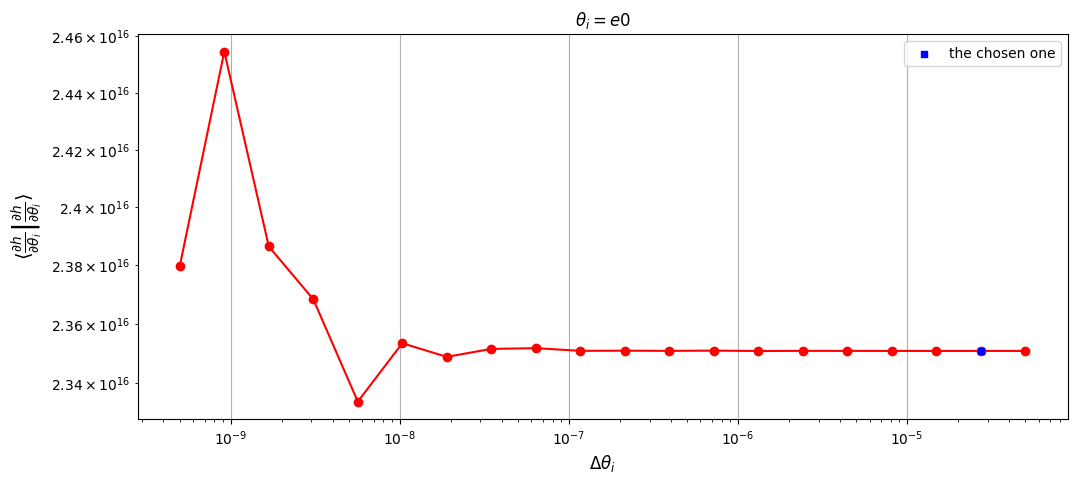

Gamma_ii for qS: 872130.9772526142
Gamma_ii for qS: 1598422.3212066568
Gamma_ii for qS: 1400142.7963174866
Gamma_ii for qS: 1424935.8875869124
Gamma_ii for qS: 1543879.2383352618
Gamma_ii for qS: 1357859.539778576
Gamma_ii for qS: 1994961.1579124862
Gamma_ii for qS: 1615385.904116465
Gamma_ii for qS: 1644886.9524114768
Gamma_ii for qS: 1599737.5523622774
Gamma_ii for qS: 1599885.662161462
Gamma_ii for qS: 1601118.48907381
Gamma_ii for qS: 1600190.3806191718
Gamma_ii for qS: 1597636.2313345594
Gamma_ii for qS: 1607456.693130191
Gamma_ii for qS: 1590244.0009057329
Gamma_ii for qS: 1590581.3261885522
Gamma_ii for qS: 1605426.6532810843
Gamma_ii for qS: 1608891.6432363647
Gamma_ii for qS: 1601397.3520109532
[np.float64(0.4543801311569283), np.float64(0.14161378782983056), np.float64(0.017399443361211287), np.float64(0.07704187464597555), np.float64(0.13699480182392043), np.float64(0.31935539978160227), np.float64(0.2349749696519915), np.float64(0.017935000488490657), np.float64(0.028223004

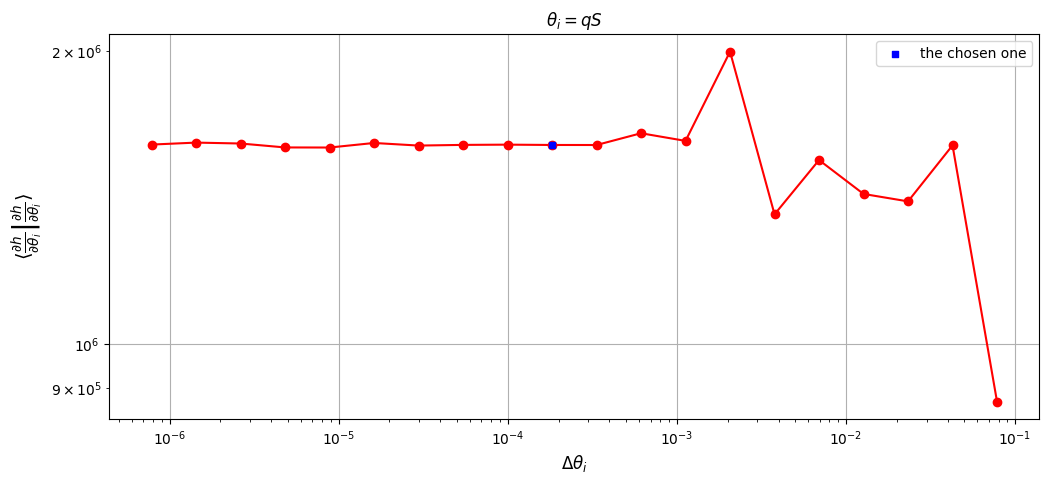

Gamma_ii for phiS: 7860401.53175905
Gamma_ii for phiS: 8719577.910344446
Gamma_ii for phiS: 8794441.879607046
Gamma_ii for phiS: 8784427.93305951
Gamma_ii for phiS: 8787260.410479581
Gamma_ii for phiS: 8786758.526238333
Gamma_ii for phiS: 8786796.530986914
Gamma_ii for phiS: 8787027.078893194
Gamma_ii for phiS: 8786982.389355436
Gamma_ii for phiS: 8786462.130686902
Gamma_ii for phiS: 8784735.178056063
Gamma_ii for phiS: 8789271.527876467
Gamma_ii for phiS: 8780956.97578742
Gamma_ii for phiS: 8780120.86159627
Gamma_ii for phiS: 8774540.764721336
Gamma_ii for phiS: 8811565.044367986
Gamma_ii for phiS: 8770922.14211125
Gamma_ii for phiS: 8716447.678244557
Gamma_ii for phiS: 8811158.895215038
Gamma_ii for phiS: 8829242.920837574
[np.float64(0.09853417073848436), np.float64(0.008512645860585871), np.float64(0.0011399657011072369), np.float64(0.0003223390781378416), np.float64(5.711824670597946e-05), np.float64(4.325210951107423e-06), np.float64(2.623730463211495e-05), np.float64(5.085879973

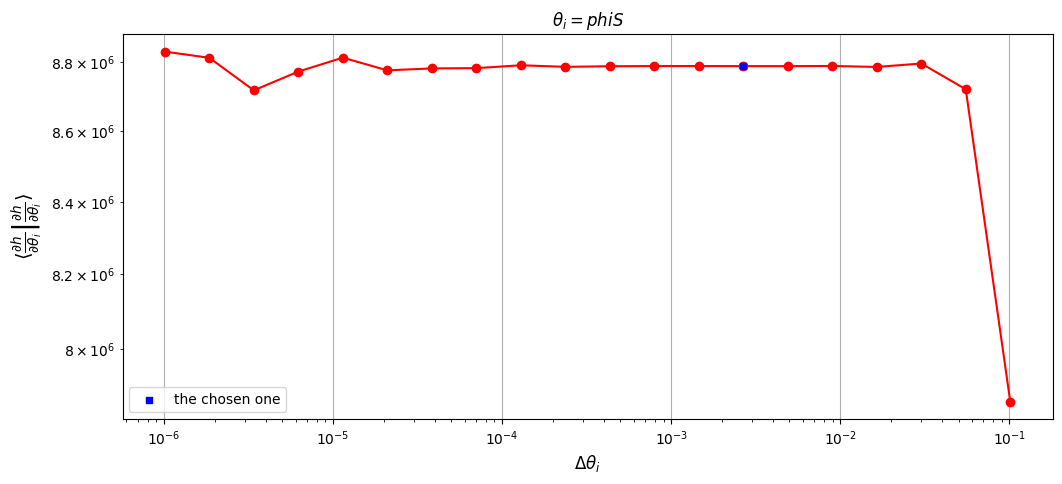

stable deltas: {'m1': 29.767010108540543, 'm2': 0.00029765739874574817, 'a': 2.678960738019527e-05, 'p0': 6.643577483543734e-05, 'e0': 2.7277106778979488e-05, 'qS': 0.00018295405809557388, 'phiS': 0.002665584822965676, 'Phi_phi0': 0.0, 'Phi_r0': 0.0}
Time taken to compute stable deltas is 35.78329396247864 seconds
calculating Fisher matrix...
Finished derivatives
Calculated Fisher is *atleast* positive-definite.
Time taken to compute FM is 1.8236463069915771 seconds


In [10]:
x_best_fit_0PA = [1000117.4489066871, 10.000747713536276, 0.9000821275834304, 7.499521999767378, 0.49998410573186125, 0.7832871364017695, 1.010973741062668, 1.0747886916109437, 0.38364873884565026]

add_kwargs_0PA = {'chi2': 0.0, 'evolve_1PA': False, 'evolve_primary': False,
                      'evolve_2PA': False, 'deviation_included': True,
                      'dev_1': 0, 'dev_2': 0}


m1, m2, a, p0, e0,qS,phiS,Phi_phi0,Phi_r0 = x_best_fit_0PA
wave_params = [m1, m2, a, p0, e0, ctx['Y0'],ctx['dist'],qS,phiS, ctx['qK'], ctx['phiK'], 
                    Phi_phi0, ctx['Phi_theta0'], Phi_r0,add_kwargs_0PA['chi2'],add_kwargs_0PA['evolve_1PA'],add_kwargs_0PA['evolve_primary'],
                    add_kwargs_0PA['evolve_2PA'], add_kwargs_0PA['deviation_included'],add_kwargs_0PA['dev_1'],add_kwargs_0PA['dev_2']]


param_names_to_infer = ['m1', 'm2', 'a', 'p0', 'e0', 'qS', 'phiS', 'Phi_phi0', 'Phi_r0']  
dim = len(param_names_to_infer)
param_names = param_names_to_infer
SNR = sef.SNRcalc_SEF(*wave_params,**emri_kwargs,use_gpu=use_gpu)
print("SNR: ", SNR)

param_dict = {
    'm1': wave_params[0],
    'm2': wave_params[1],
    'a': wave_params[2],
    'p0': wave_params[3],
    'e0': wave_params[4],
    'xI0': wave_params[5],
    'dist': wave_params[6],
    'qS': wave_params[7],
    'phiS': wave_params[8],
    'qK': wave_params[9],
    'phiK': wave_params[10],
    'Phi_phi0': wave_params[11],
    'Phi_theta0': wave_params[12],
    'Phi_r0': wave_params[13]}

Fisher_0PA = sef(wave_params = param_dict,param_names=param_names, add_param_args=add_kwargs_0PA,
            live_dangerously = False, stability_plot = True,der_order = 8, Ndelta = 20,return_derivatives = False)

# Covariance_fit_0PA = fishinv(m1, Fisher, index_of_M=0)

waveform shape: (3, 3155814)
wave ndim: 2


Computing SNR for parameters: (1000008.5746504833, 9.999570425057946, 0.9000237990385593, 7.499889256379131, 0.500009070433986, np.float64(1.0), np.float64(5.0), 0.7832270952980772, 1.0127652339855113, np.float64(1.0), np.float64(1.0471975511965976), 1.0921650231160118, np.float64(0.5), 0.3960954729726116, 0.0, False, False, False, True, 2.412658875547302, -2.571125543385933)
SNR:  179.65008388196972
Body is not plunging, Fisher should be stable.
waveform shape: (3, 3155814)
wave ndim: 2
Computing SNR for parameters: (1000008.5746504833, 9.999570425057946, 0.9000237990385593, 7.499889256379131, 0.500009070433986, np.float64(1.0), np.float64(5.0), 0.7832270952980772, 1.0127652339855113, np.float64(1.0), np.float64(1.0471975511965976), 1.0921650231160118, np.float64(0.5), 0.3960954729726116, 0.0, False, False, False, True, 2.412658875547302, -2.571125543385933)
Waveform Generated. SNR: 179.65008388196972
calculating stable deltas...
Gamma_ii for m1: 64437.79653967222
Gamma_ii for m1: 644

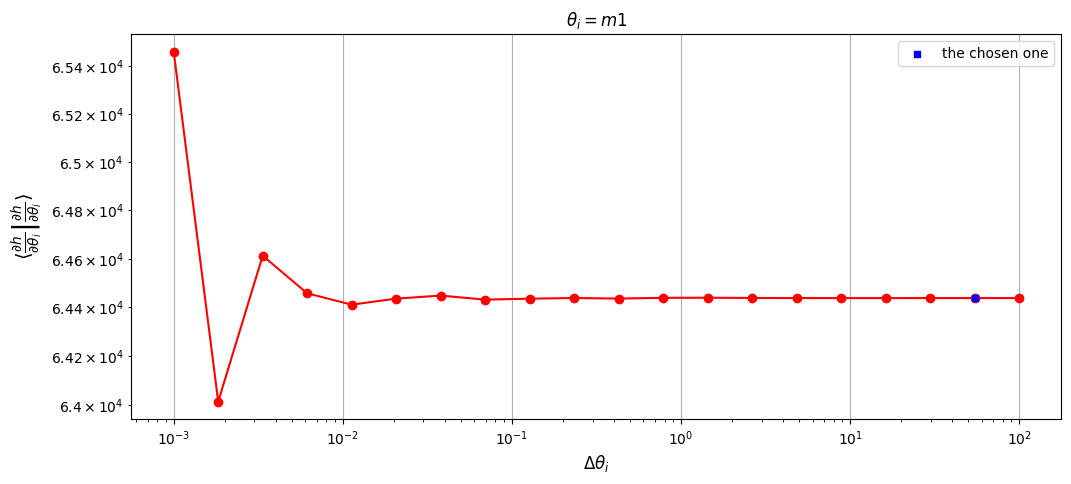

Gamma_ii for m2: 39277920535077.03
Gamma_ii for m2: 39277948617483.445
Gamma_ii for m2: 39277971152191.13
Gamma_ii for m2: 39278117000700.0
Gamma_ii for m2: 39277829602967.55
Gamma_ii for m2: 39277793984550.945
Gamma_ii for m2: 39279553833641.47
Gamma_ii for m2: 39280692844070.984
Gamma_ii for m2: 39276653211778.0
Gamma_ii for m2: 39272618486696.39
Gamma_ii for m2: 39278617926552.54
Gamma_ii for m2: 39271942338132.09
Gamma_ii for m2: 39262046939586.15
Gamma_ii for m2: 39303153041878.82
Gamma_ii for m2: 39272295110276.98
Gamma_ii for m2: 39210762769377.64
Gamma_ii for m2: 39326679745009.77
Gamma_ii for m2: 39709079039861.85
Gamma_ii for m2: 38238340703437.54
Gamma_ii for m2: 41820869511325.59
[np.float64(7.149662190240359e-07), np.float64(5.737238209220207e-07), np.float64(3.7132255821883786e-06), np.float64(7.317047183060525e-06), np.float64(9.068334289744536e-07), np.float64(4.4803184322735167e-05), np.float64(2.8996699066308524e-05), np.float64(0.00010285072588040672), np.float64(0.0

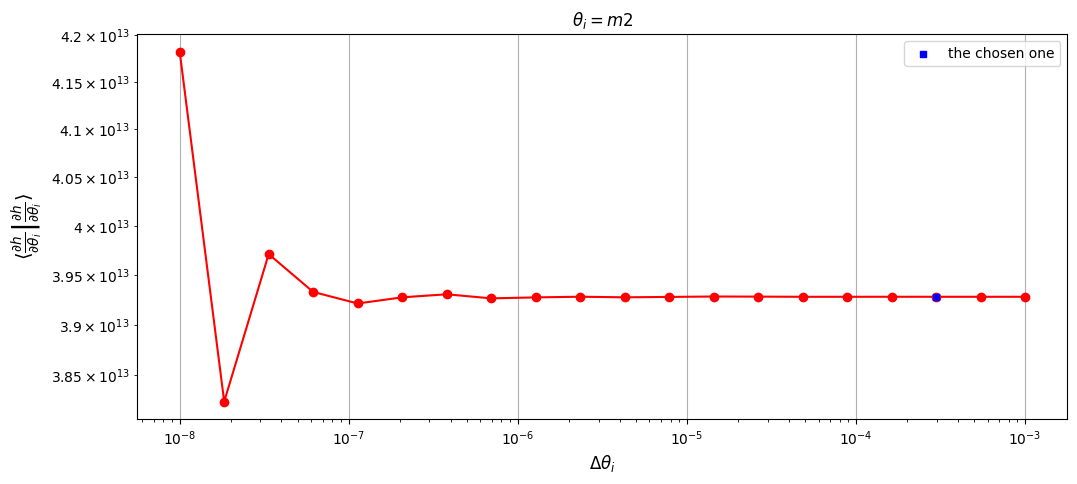

Gamma_ii for a: 3179129393135229.0
Gamma_ii for a: 3179128186446801.0
Gamma_ii for a: 3179130210092961.0
Gamma_ii for a: 3179117849076512.5
Gamma_ii for a: 3179179813974903.0
Gamma_ii for a: 3179017144067563.0
Gamma_ii for a: 3179116652490524.0
Gamma_ii for a: 3179250013853345.0
Gamma_ii for a: 3179776099758874.5
Gamma_ii for a: 3179779406193903.5
Gamma_ii for a: 3179648717083125.5
Gamma_ii for a: 3180014646842336.5
Gamma_ii for a: 3182015592604837.5
Gamma_ii for a: 3185315279739824.0
Gamma_ii for a: 3195684163397223.0
Gamma_ii for a: 3177785914021687.5
Gamma_ii for a: 3225509974656252.0
Gamma_ii for a: 3274010620438938.0
Gamma_ii for a: 3199273105284982.5
Gamma_ii for a: 3206634138430901.0
[np.float64(3.7956582975934446e-07), np.float64(6.365408228877881e-07), np.float64(3.888190697960661e-06), np.float64(1.9490844185068534e-05), np.float64(5.1169874199502844e-05), np.float64(3.130065167097438e-05), np.float64(4.194742855701433e-05), np.float64(0.00016544746831998443), np.float64(1.03

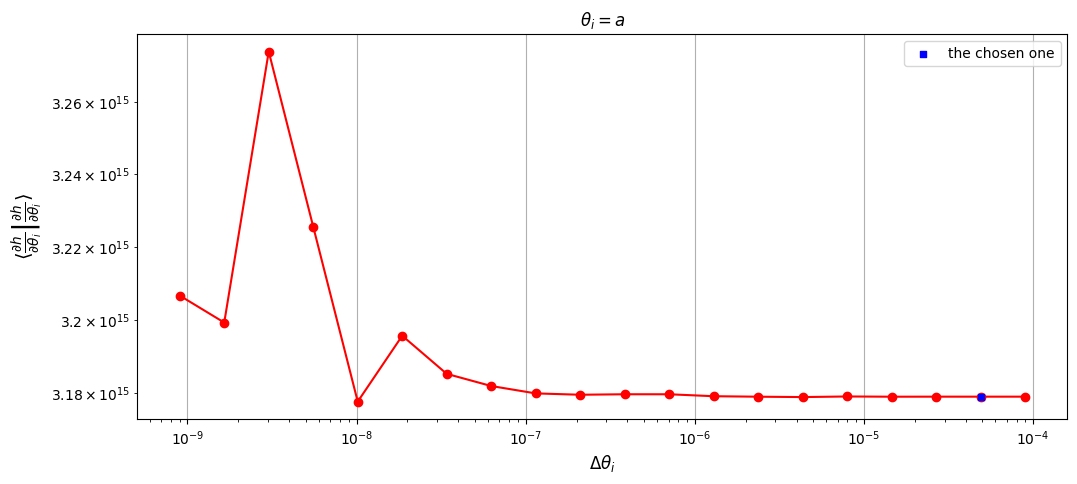

Gamma_ii for p0: 3138407094996754.5
Gamma_ii for p0: 3138406997297888.0
Gamma_ii for p0: 3138406734842083.0
Gamma_ii for p0: 3138407076185368.0
Gamma_ii for p0: 3138407797607381.0
Gamma_ii for p0: 3138411280237132.5
Gamma_ii for p0: 3138400721748160.5
Gamma_ii for p0: 3138398355527548.5
Gamma_ii for p0: 3138390144578020.5
Gamma_ii for p0: 3138430534191040.5
Gamma_ii for p0: 3138535098603332.0
Gamma_ii for p0: 3138369900402619.5
Gamma_ii for p0: 3138303731323765.0
Gamma_ii for p0: 3138150238511518.5
Gamma_ii for p0: 3138972506603783.0
Gamma_ii for p0: 3137948444796313.0
Gamma_ii for p0: 3141264343307886.0
Gamma_ii for p0: 3131744266153133.0
Gamma_ii for p0: 3126122747518878.0
Gamma_ii for p0: 3129918495634869.5
[np.float64(3.1130081784840834e-08), np.float64(8.362708443308453e-08), np.float64(1.0876322819628985e-07), np.float64(2.2986879319825436e-07), np.float64(1.1096792104433359e-06), np.float64(3.364289620134513e-06), np.float64(7.539580206038728e-07), np.float64(2.616293433812074e-

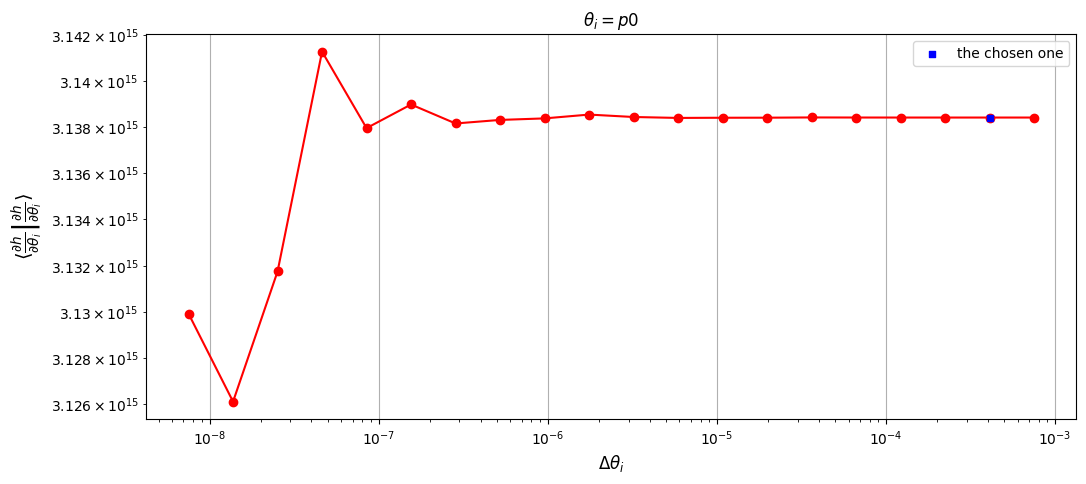

Gamma_ii for e0: 2.416741456905788e+16
Gamma_ii for e0: 2.41674063175701e+16
Gamma_ii for e0: 2.416747729795947e+16
Gamma_ii for e0: 2.4167379444677936e+16
Gamma_ii for e0: 2.4167448644275196e+16
Gamma_ii for e0: 2.416763056670197e+16
Gamma_ii for e0: 2.416774946520972e+16
Gamma_ii for e0: 2.4168135728598664e+16
Gamma_ii for e0: 2.416498406317944e+16
Gamma_ii for e0: 2.4169233590086704e+16
Gamma_ii for e0: 2.41745859818679e+16
Gamma_ii for e0: 2.4160145235206828e+16
Gamma_ii for e0: 2.416527355940768e+16
Gamma_ii for e0: 2.4197076725057028e+16
Gamma_ii for e0: 2.4191425658583224e+16
Gamma_ii for e0: 2.4259184847066356e+16
Gamma_ii for e0: 2.4179434890319092e+16
Gamma_ii for e0: 2.419018986747957e+16
Gamma_ii for e0: 2.4102322480463336e+16
Gamma_ii for e0: 2.202856621870755e+16
[np.float64(3.414304237522184e-07), np.float64(2.9370210426552493e-06), np.float64(4.048981883203267e-06), np.float64(2.863338959712326e-06), np.float64(7.527524316870837e-06), np.float64(4.919717821601815e-06), 

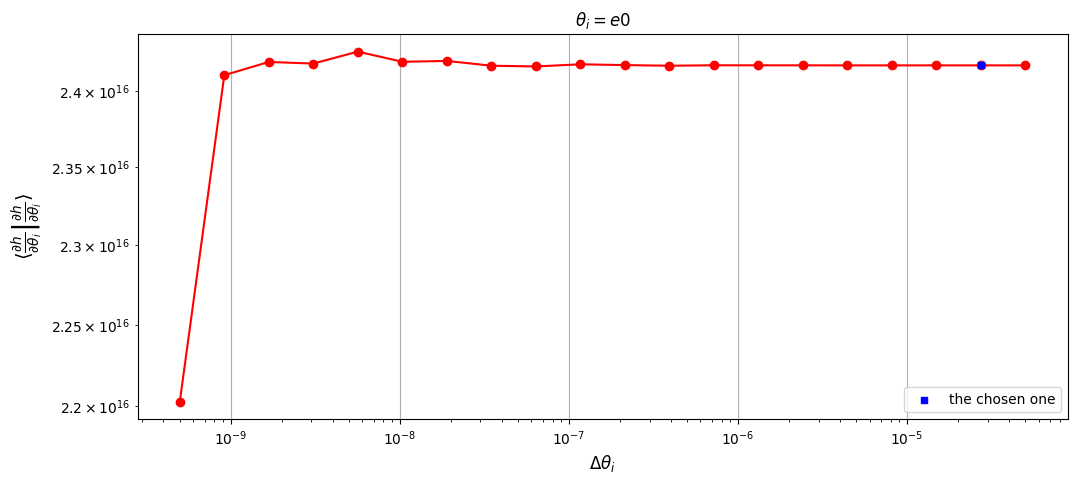

Gamma_ii for qS: 887142.0189280157
Gamma_ii for qS: 1622584.556133542
Gamma_ii for qS: 1427694.7012520249
Gamma_ii for qS: 1453507.9073123788
Gamma_ii for qS: 1600835.9549357952
Gamma_ii for qS: 1408305.2859340054
Gamma_ii for qS: 1571211.1050611145
Gamma_ii for qS: 1656827.4567424164
Gamma_ii for qS: 1671746.6652465954
Gamma_ii for qS: 1623372.6876785157
Gamma_ii for qS: 1624552.305335962
Gamma_ii for qS: 1626839.9214605498
Gamma_ii for qS: 1625285.8009736326
Gamma_ii for qS: 1633152.745168691
Gamma_ii for qS: 1592257.1328100439
Gamma_ii for qS: 1603148.9474375679
Gamma_ii for qS: 1577118.077593505
Gamma_ii for qS: 1563987.9045533503
Gamma_ii for qS: 1579613.1635509084
Gamma_ii for qS: 1588747.5182429748
[np.float64(0.4532537515074178), np.float64(0.136506673808208), np.float64(0.017759247081141807), np.float64(0.09203194566511676), np.float64(0.13671088997873146), np.float64(0.10368168771361419), np.float64(0.05167487497439055), np.float64(0.008924323771256532), np.float64(0.02979844

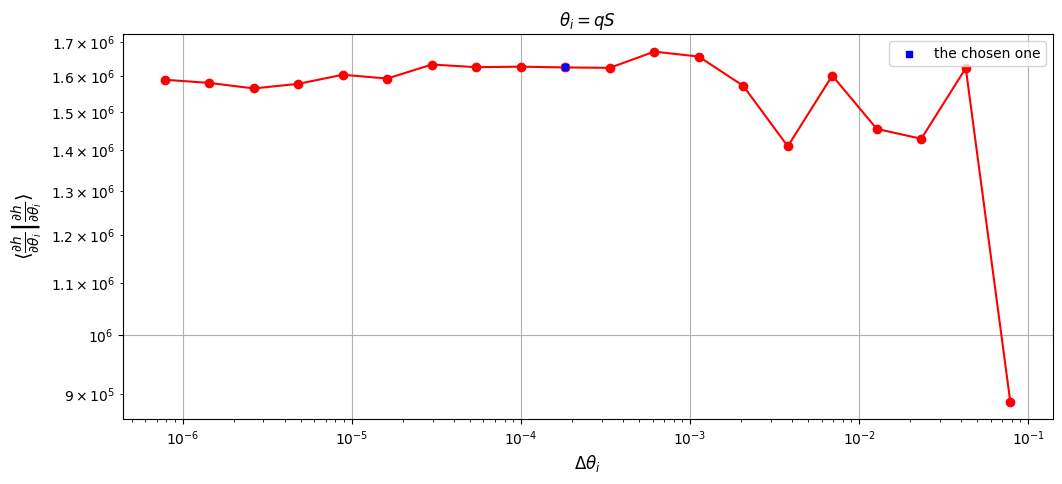

Gamma_ii for phiS: 8071476.016655873
Gamma_ii for phiS: 8968965.177757975
Gamma_ii for phiS: 9036084.010658005
Gamma_ii for phiS: 9042102.291188464
Gamma_ii for phiS: 9037999.61949025
Gamma_ii for phiS: 9039542.885286424
Gamma_ii for phiS: 9039696.176726714
Gamma_ii for phiS: 9039199.158300888
Gamma_ii for phiS: 9041585.589898475
Gamma_ii for phiS: 9038714.326226134
Gamma_ii for phiS: 9037753.18703199
Gamma_ii for phiS: 9044347.143530782
Gamma_ii for phiS: 9032121.950414782
Gamma_ii for phiS: 9028016.10304056
Gamma_ii for phiS: 9098340.530921469
Gamma_ii for phiS: 8911100.209785156
Gamma_ii for phiS: 8964018.99603917
Gamma_ii for phiS: 8876423.488634042
Gamma_ii for phiS: 8800420.893969873
Gamma_ii for phiS: 8847383.021295996
[np.float64(0.10006607711308484), np.float64(0.007427867295264662), np.float64(0.0006655842122382464), np.float64(0.00045393581223074673), np.float64(0.0001707238757268562), np.float64(1.6957587654784945e-05), np.float64(5.498478539103332e-05), np.float64(0.000263

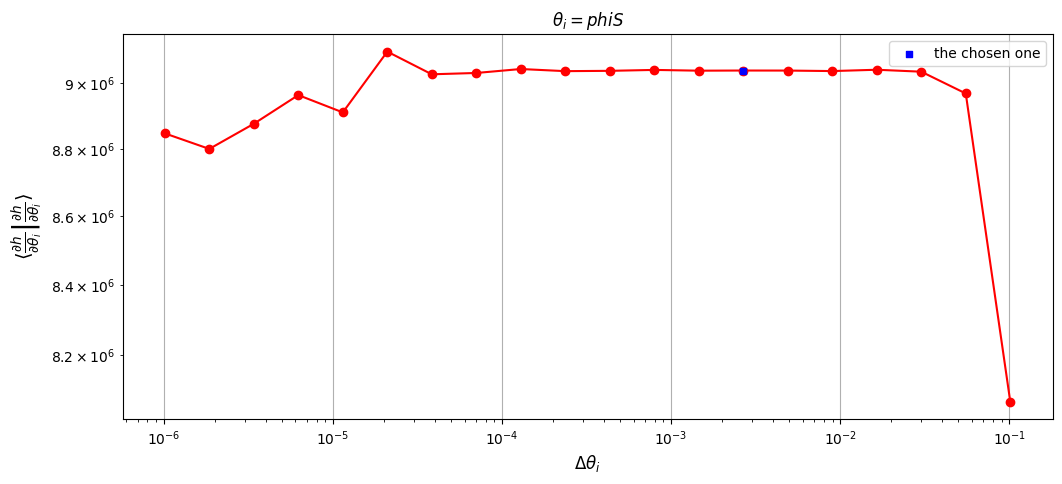

Gamma_ii for dev_1: 254099.79290798464
Gamma_ii for dev_1: 254094.38539465432
Gamma_ii for dev_1: 254105.49124804442
Gamma_ii for dev_1: 254169.21739626594
Gamma_ii for dev_1: 254156.46565384805
Gamma_ii for dev_1: 254306.97722946352
Gamma_ii for dev_1: 254068.9812089344
Gamma_ii for dev_1: 253674.66060720943
Gamma_ii for dev_1: 255177.28650554214
Gamma_ii for dev_1: 252718.07546308608
Gamma_ii for dev_1: 254988.56819032016
Gamma_ii for dev_1: 255099.64183484376
Gamma_ii for dev_1: 256548.0619286297
Gamma_ii for dev_1: 244950.53841011185
Gamma_ii for dev_1: 280296.75826577493
Gamma_ii for dev_1: 303362.6441228025
Gamma_ii for dev_1: 654471.9232490348
Gamma_ii for dev_1: 1816.7308791791481
Gamma_ii for dev_1: 657353.2817982354
Gamma_ii for dev_1: 688040.9599998851
[np.float64(2.12815144337541e-05), np.float64(4.3705680406777106e-05), np.float64(0.0002507233128950161), np.float64(5.0172803533011105e-05), np.float64(0.000591849965168915), np.float64(0.0009367378079633082), np.float64(0.00

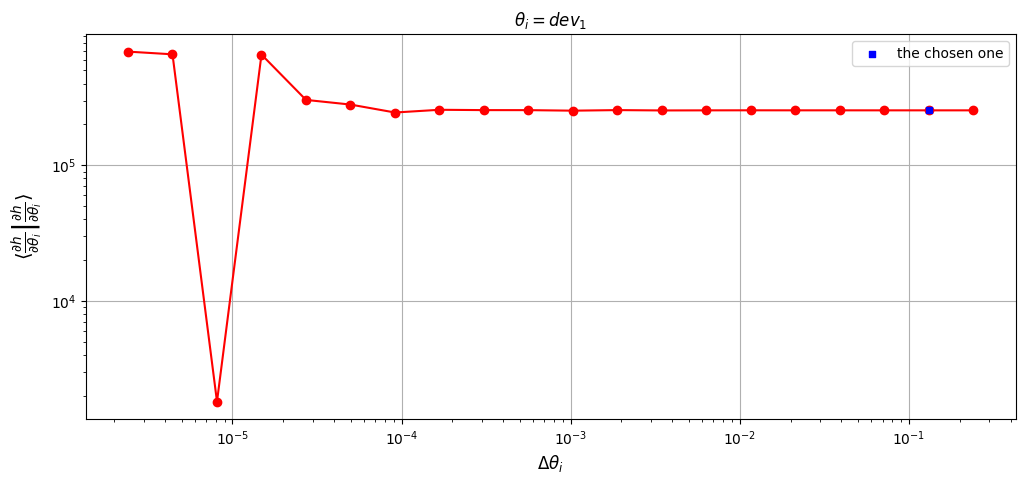

Gamma_ii for dev_2: 15052.948118907527
Gamma_ii for dev_2: 15056.142604200815
Gamma_ii for dev_2: 15062.13243615302
Gamma_ii for dev_2: 15047.405555842917
Gamma_ii for dev_2: 15057.903248725772
Gamma_ii for dev_2: 15074.104637486957
Gamma_ii for dev_2: 15067.890615573004
Gamma_ii for dev_2: 15162.384927635314
Gamma_ii for dev_2: 14953.16321718388
Gamma_ii for dev_2: 15628.392771714562
Gamma_ii for dev_2: 15670.70411709337
Gamma_ii for dev_2: 14446.087533036469
Gamma_ii for dev_2: 13668.828844870608
Gamma_ii for dev_2: 16724.736796475743
Gamma_ii for dev_2: 23656.041437597323
Gamma_ii for dev_2: 23983.709733957192
Gamma_ii for dev_2: 49938.312977405156
Gamma_ii for dev_2: 27765.467402060523
Gamma_ii for dev_2: 24237.830134006224
Gamma_ii for dev_2: 566286.1343408017
[np.float64(0.0002121715619508736), np.float64(0.0003976748961407484), np.float64(0.0009786989694303043), np.float64(0.0006971550228112233), np.float64(0.001074782824639175), np.float64(0.0004124015811165027), np.float64(0.0

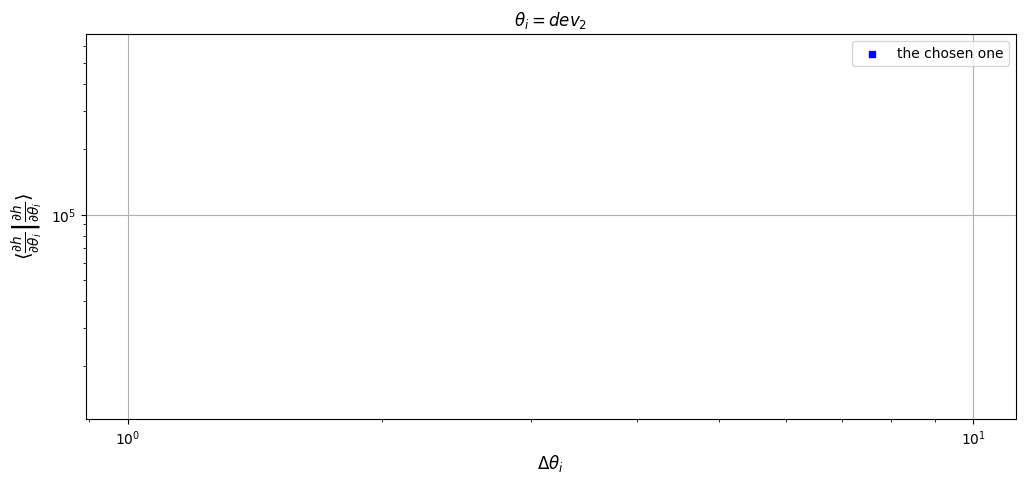

stable deltas: {'m1': 54.5564156098695, 'm2': 0.0002976223585031511, 'a': 4.910165140962227e-05, 'p0': 0.00040916356686443835, 'e0': 2.727846875196573e-05, 'qS': 0.00018294003416608143, 'phiS': 0.0026703083643907603, 'Phi_phi0': 0.0, 'Phi_r0': 0.0, 'dev_1': 0.13162489170175773, 'dev_2': -0.1402701909622537}
Time taken to compute stable deltas is 43.37387943267822 seconds
calculating Fisher matrix...
Finished derivatives
Calculated Fisher is *atleast* positive-definite.
Time taken to compute FM is 2.268559694290161 seconds


In [11]:
x_best_fit_0PA_dev = [1000008.5746504833, 9.999570425057946, 0.9000237990385593, 7.499889256379131, 0.500009070433986, 0.7832270952980772, 1.0127652339855113, 1.0921650231160118, 0.3960954729726116, 2.412658875547302, -2.571125543385933]

add_kwargs_0PA_dev = {'chi2': 0.0, 'evolve_1PA': False, 'evolve_primary': False,
                      'evolve_2PA': False, 'deviation_included': True,
                      'dev_1': x_best_fit_0PA_dev[9], 'dev_2': x_best_fit_0PA_dev[10]}


m1, m2, a, p0, e0,qS,phiS,Phi_phi0,Phi_r0,dev_1,dev_2 = x_best_fit_0PA_dev
wave_params = [m1, m2, a, p0, e0, ctx['Y0'],ctx['dist'],qS,phiS, ctx['qK'], ctx['phiK'], 
                    Phi_phi0, ctx['Phi_theta0'], Phi_r0,add_kwargs_0PA_dev['chi2'],add_kwargs_0PA_dev['evolve_1PA'],
                    add_kwargs_0PA_dev['evolve_primary'],add_kwargs_0PA_dev['evolve_2PA'],
                      add_kwargs_0PA_dev['deviation_included'],add_kwargs_0PA_dev['dev_1'],add_kwargs_0PA_dev['dev_2']]


param_names_to_infer = ['m1', 'm2', 'a', 'p0', 'e0', 'qS', 'phiS', 'Phi_phi0', 'Phi_r0','dev_1','dev_2']  
dim = len(param_names_to_infer)
param_names = param_names_to_infer
SNR = sef.SNRcalc_SEF(*wave_params,**emri_kwargs,use_gpu=use_gpu)
print("SNR: ", SNR)

param_dict = {
    'm1': wave_params[0],
    'm2': wave_params[1],
    'a': wave_params[2],
    'p0': wave_params[3],
    'e0': wave_params[4],
    'xI0': wave_params[5],
    'dist': wave_params[6],
    'qS': wave_params[7],
    'phiS': wave_params[8],
    'qK': wave_params[9],
    'phiK': wave_params[10],
    'Phi_phi0': wave_params[11],
    'Phi_theta0': wave_params[12],
    'Phi_r0': wave_params[13]}

Fisher_0PA_dev = sef(wave_params = param_dict,param_names=param_names, add_param_args=add_kwargs_0PA_dev,
            live_dangerously = False, stability_plot = True,der_order = 8, Ndelta = 20,return_derivatives = False)

# Covariance_fit_0PA_dev = fishinv(m1, Fisher, index_of_M=0)

In [12]:
np.save("1gen_results/Fisher_1PA_emri.npy", Fisher_1PA)
np.save("1gen_results/Fisher_0PA_emri.npy", Fisher_0PA)
np.save("1gen_results/Fisher_0PA_dev_simple_emri.npy", Fisher_0PA_dev)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2

# ── Best-fit values ───────────────────────────────────────────────────────────
x_best_fit_1PA = np.array([999894.8642207884, 9.999204206491733, 0.8999403453809603, 7.5003883272499, 0.500021423957347, 0.7911479980488584, 1.0103259004865965, 1.0674353740287845, 0.3675965889561167])

x_best_fit_0PA = np.array([1000117.4489066871, 10.000747713536276, 0.9000821275834304, 7.499521999767378, 0.49998410573186125, 0.7832871364017695, 1.010973741062668, 1.0747886916109437, 0.38364873884565026])

x_best_fit_0PA_dev = np.array([1000008.5746504833, 9.999570425057946, 0.9000237990385593, 7.499889256379131, 0.500009070433986, 0.7832270952980772, 1.0127652339855113, 1.0921650231160118, 0.3960954729726116, 2.412658875547302, -2.571125543385933])
# True injected parameters — order MUST match `labels` below.
signal_param = {"m1": 1e6,
    "m2": 10.0,
    "a": 0.9,
    "p0": 7.5,
    "e0": 0.5,
    "xI0": 1.0,
    "dist": 5.0,
    "qS": np.pi/4,
    "phiS": 1,
    "qK": 1,
    "phiK": np.pi/3,
    "Phi_phi0": 0.9,
    "Phi_theta0": 0.5,
    "Phi_r0": 4.00000000e-01,
}
true_params = np.array([
    signal_param["m1"], signal_param["m2"], signal_param["a"],
    signal_param["p0"], signal_param["e0"],
    signal_param["qS"], signal_param["phiS"],
    signal_param["Phi_phi0"], signal_param["Phi_r0"],
    0.0, 0.0,            # dev_1, dev_2 — true injection (0 if no deviation)
])

labels = [r'$M_1\ (M_\odot)$', r'$M_2\ (M_\odot)$', r'$a$',
          r'$p_0\ (M)$', r'$e_0$', r'$q_S$', r'$\phi_S$',
          r'$\Phi_{\phi_0}$', r'$\Phi_{r_0}$',
          r'$\delta_1$', r'$\delta_2$']

# ── Per-fit configuration ─────────────────────────────────────────────────────
fits = [
    ('1PA',       x_best_fit_1PA,     Covariance_fit_1PA,     '#534AB7', 9),
    ('0PA',       x_best_fit_0PA,     Covariance_fit_0PA,     '#0F6E56', 9),
    ('0PA + dev', x_best_fit_0PA_dev, Covariance_fit_0PA_dev, '#D85A30', 11),
]

LEVELS         = (0.80,)
LEVEL_STYLES   = {0.80: '-'}
N_PARAMS_TOTAL = 11
TRUTH_COLOR    = '#000000'


# ── Confidence-ellipse helper ─────────────────────────────────────────────────
def draw_ellipses(ax, mean, cov, i, j, color, levels, styles):
    cov2  = cov[np.ix_([i, j], [i, j])]
    mean2 = mean[[i, j]]

    eigvals, eigvecs = np.linalg.eigh(cov2)
    order   = np.argsort(eigvals)[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]

    theta = np.linspace(0, 2 * np.pi, 400)
    for p in levels:
        chi2_val = chi2.ppf(p, df=2)
        r1 = np.sqrt(eigvals[0] * chi2_val)
        r2 = np.sqrt(eigvals[1] * chi2_val)
        ellipse = np.vstack([r1 * np.cos(theta), r2 * np.sin(theta)])
        ellipse = eigvecs @ ellipse + mean2[:, None]
        ax.plot(ellipse[0], ellipse[1], color=color, lw=1.2, ls=styles[p])


# ── Combined corner plot ──────────────────────────────────────────────────────
def combined_triangle_plot():
    D = N_PARAMS_TOTAL
    fig, axes = plt.subplots(D, D, figsize=(2.2 * D, 2.2 * D))

    if len(true_params) != D:
        raise ValueError(
            f"true_params has {len(true_params)} entries; expected {D} to match labels.")

    for i in range(D):
        for j in range(D):
            ax = axes[i, j]

            if j >= i:
                ax.axis('off')
                continue

            for name, mean, cov, color, n in fits:
                if i >= n or j >= n:
                    continue
                draw_ellipses(ax, mean, cov, j, i, color, LEVELS, LEVEL_STYLES)
                ax.scatter(mean[j], mean[i], color=color, s=10, zorder=3)

            ax.axvline(true_params[j], color=TRUTH_COLOR, lw=0.8, ls='--', alpha=0.6)
            ax.axhline(true_params[i], color=TRUTH_COLOR, lw=0.8, ls='--', alpha=0.6)
            ax.scatter(true_params[j], true_params[i],
                       color=TRUTH_COLOR, marker='*', s=60, zorder=5,
                       edgecolor='white', linewidth=0.6)

            if i == D - 1:
                ax.set_xlabel(labels[j], fontsize=10)
                ax.tick_params(axis='x', labelrotation=45)
            else:
                ax.set_xticklabels([])
            if j == 0:
                ax.set_ylabel(labels[i], fontsize=10)
            else:
                ax.set_yticklabels([])

            ax.tick_params(labelsize=7)

    legend_handles = [plt.Line2D([0], [0], color=color, lw=2, label=name)
                      for name, _, _, color, _ in fits]
    legend_handles.append(plt.Line2D([0], [0], color='black', lw=1.2, ls='-',
                                     label='80% CL'))
    legend_handles.append(plt.Line2D([0], [0], color=TRUTH_COLOR, marker='*',
                                     ls='--', lw=0.8, markersize=10,
                                     markeredgecolor='white', markeredgewidth=0.6,
                                     label='truth'))

    fig.legend(handles=legend_handles, loc='upper right',
               bbox_to_anchor=(0.98, 0.98), fontsize=11, frameon=True)

    fig.suptitle('Combined corner plot — 1PA, 0PA, 0PA + deviation (80% CL)',
                 fontsize=15, y=1.005)
    plt.tight_layout()
    plt.show()


combined_triangle_plot()